# 44 — Aggregate IMA capital for eligible desks

Apply current-versus-average rules, the backtesting multiplier, IMA DRC and the amber surcharge.

The non-DRC component compares current IMCC plus SES with multiplier-adjusted 60-day average IMCC plus average SES. IMA DRC compares current with its 12-week average.

This step uses: IMCC and SES histories, bank-wide exceptions, IMA DRC and amber-desk SA comparison.

It produces: Eligible-desk IMA capital with every component shown separately.

> Basel norm applied: MAR33.22 and MAR33.41–MAR33.45 prescribe the averaging, multiplier and amber-surcharge treatment.

$$C_A=\max(IMCC_t+SES_t,\ m_c\overline{IMCC}_{60}+\overline{SES}_{60})$$

Synthetic inputs are labelled directly in the displayed data. Basel regulatory parameters are loaded separately from versioned configuration.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from frtb_engine.notebook_tools import INR_CRORE, configure_notebooks, crore_table, draw_flow, heatmap

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_ima_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
MANIFEST = json.loads((RUN / 'run_manifest.json').read_text(encoding='utf-8'))
STAGES = {row['stage']: ROOT / row['path'] for row in MANIFEST['artifacts']}
SUMMARY = json.loads((RUN / '27_combined_capital_summary.json').read_text(encoding='utf-8'))

def stage(name):
    return pd.read_csv(STAGES[name])

def money(value):
    return f"INR {float(value) / INR_CRORE:,.2f} crore"

print(f'IMA calculation run used: {RUN_ID}')
print('Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled')

IMA calculation run used: IMA_20260901T122303Z
Reporting currency: INR | Synthetic and regulatory inputs remain separately labelled


In [2]:
history=stage('24_ima_capital_history'); bank=stage('26_bankwide_backtesting'); history['date']=pd.to_datetime(history.date)
current=SUMMARY['imcc_current_inr']+SUMMARY['ses_current_inr']; average=SUMMARY['backtesting_multiplier']*SUMMARY['imcc_average_60_day_inr']+SUMMARY['ses_average_60_day_inr']
print(f"Current IMCC + SES = {money(current)}")
print(f"Multiplier-adjusted average IMCC + average SES = {money(average)}")
print(f"Selected non-DRC capital = {money(SUMMARY['ima_non_drc_capital_inr'])}")
display(bank)

Current IMCC + SES = INR 39.15 crore
Multiplier-adjusted average IMCC + average SES = INR 57.16 crore
Selected non-DRC capital = INR 57.16 crore


,observations,hpl_exceptions_99,apl_exceptions_99,exceptions_used,exception_rule,multiplier
0,250,1,1,1,Maximum of bank-wide HPL and APL exceptions,1.5000


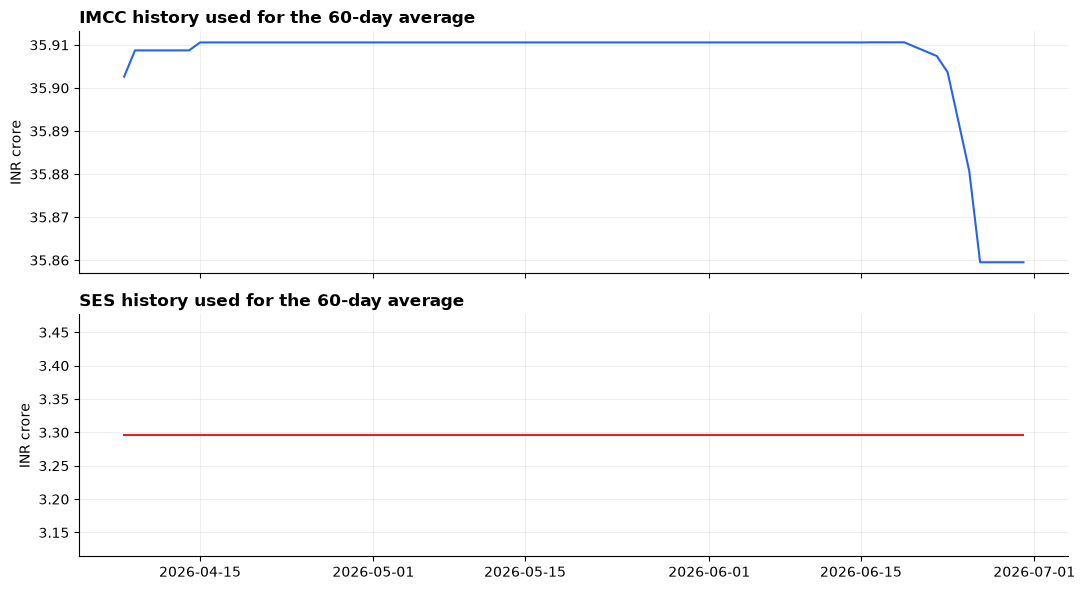

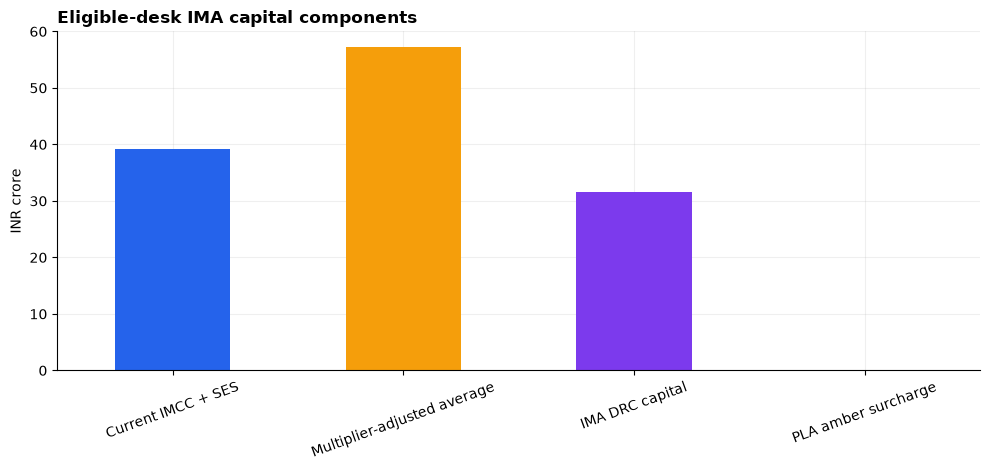

In [3]:
fig,axes=plt.subplots(2,1,sharex=True,figsize=(11,6)); axes[0].plot(history.date,history.imcc_inr/INR_CRORE,color='#2563EB'); axes[0].set_ylabel('INR crore'); axes[0].set_title('IMCC history used for the 60-day average',loc='left',weight='bold'); axes[1].plot(history.date,history.ses_inr/INR_CRORE,color='#DC2626'); axes[1].set_ylabel('INR crore'); axes[1].set_title('SES history used for the 60-day average',loc='left',weight='bold'); plt.tight_layout(); plt.show()
parts=pd.Series({'Current IMCC + SES':current,'Multiplier-adjusted average':average,'IMA DRC capital':SUMMARY['ima_drc_capital_inr'],'PLA amber surcharge':SUMMARY['pla_amber_surcharge_inr']})/INR_CRORE; ax=parts.plot(kind='bar',color=['#2563EB','#F59E0B','#7C3AED','#DC2626']); ax.set_ylabel('INR crore'); ax.set_title('Eligible-desk IMA capital components',loc='left',weight='bold'); ax.tick_params(axis='x',rotation=20); plt.tight_layout(); plt.show()

The two line panels show the retained 60-day histories used for the current-versus-average comparison. IMCC is recalculated from each dated 250-day window using the current calibrated stress period. SES stays level because the current NMRF stress scenarios and current constant-tenor positions are held fixed across this averaging view. The larger of current non-DRC capital and the multiplier-adjusted average becomes the charge.